## loading data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tarfile
from pathlib import Path
import urllib.request

In [3]:
def load_data():
    if not Path('datasets/titanic.tgz').is_file():
        Path('datasets').mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve('https://homl.info/titanic.tgz', 'datasets/titanic.tgz')
        with tarfile.open('datasets/titanic.tgz') as titanic_tarfile:
            titanic_tarfile.extractall(path='datasets')
    return pd.read_csv(Path('datasets/titanic/train.csv'))

In [4]:
titanic = load_data()
titanic

# survived 0-1, Pclass(Ticket class) 1-3, Sex Male-Female, Age 0.4-80, Sibsp(Number of Siblings/Spouses Aboard) 0-8, Parch(Number of Parents/Children Aboard.) 0-6, Fare(cost) 0-512 #7 params
# passengerId, Name, Ticket, Cabin are not represantative
# (port of embarkation)embarked - S, C, Q

# Survived 0-1  ---> Target value

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen 'Carrie'",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Getting insights

In [5]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699113,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526507,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.416700,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titanic.info()
#cabin and Age have missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
titanic['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [8]:
#embarked - onehot encoder,  Sex - 0-1
titanic_dropped = titanic.copy().drop(['Name', 'Cabin', 	'PassengerId', 'Ticket'], axis=1)
titanic_dropped

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [9]:
titanic_dropped['Sex'] = titanic_dropped['Sex'].map({'male':1, 'female' : 0})


titanic_dropped

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S
887,1,1,0,19.0,0,0,30.0000,S
888,0,3,0,NaN,1,2,23.4500,S
889,1,1,1,26.0,0,0,30.0000,C


In [10]:
titanic_dropped['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [11]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

titanic_cat = titanic_dropped[['Embarked']]

encoder = OneHotEncoder()

titanic_cat_1hot = encoder.fit_transform(titanic_cat)
titanic_cat_1hot.toarray()

array([[0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]], shape=(891, 4))

In [12]:
titanic_corr = titanic_dropped.corr(numeric_only=True)
titanic_corr['Survived'].sort_values(ascending=False)

Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
Pclass     -0.338481
Sex        -0.543351
Name: Survived, dtype: float64

<Axes: >

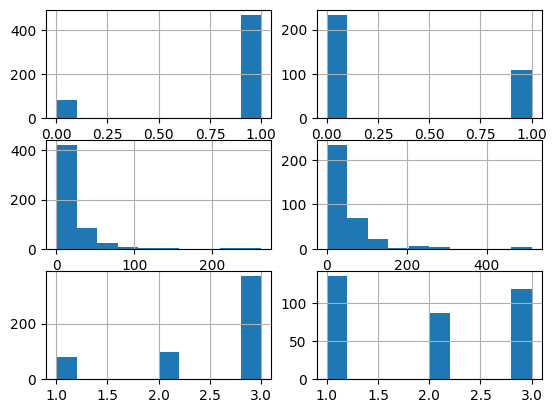

In [13]:
labels = ['Survived', 'Fare', 'Pclass', 'Sex']

titanic_survived = titanic_dropped[titanic_dropped['Survived'] == 1]
titanic_dead = titanic_dropped[titanic_dropped['Survived'] == 0]

plt.subplot(321)
titanic_dead['Sex'].hist()
plt.subplot(322)
titanic_survived['Sex'].hist()
plt.subplot(323)
titanic_dead['Fare'].hist()
plt.subplot(324)
titanic_survived['Fare'].hist()
plt.subplot(325)
titanic_dead['Pclass'].hist()
plt.subplot(326)
titanic_survived['Pclass'].hist()

<Axes: >

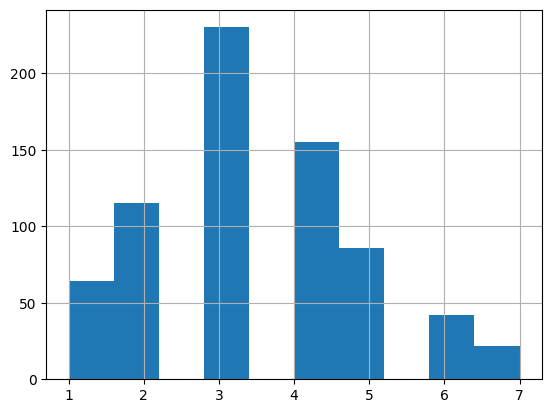

In [14]:
titanic_dropped['age_group'] = pd.cut(titanic_dropped['Age'], bins=[0, 10, 20, 30, 40, 50, 60, np.inf], labels=[1, 2, 3, 4, 5, 6, 7])
titanic_dropped['age_group'].hist()

In [15]:
titanic_dropped


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age_group
0,0,3,1,22.0,1,0,7.2500,S,3
1,1,1,0,38.0,1,0,71.2833,C,4
2,1,3,0,26.0,0,0,7.9250,S,3
3,1,1,0,35.0,1,0,53.1000,S,4
4,0,3,1,35.0,0,0,8.0500,S,4
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S,3
887,1,1,0,19.0,0,0,30.0000,S,2
888,0,3,0,NaN,1,2,23.4500,S,NaN
889,1,1,1,26.0,0,0,30.0000,C,3


In [16]:
titanic_num = titanic_dropped.copy().drop(['Embarked', 'age_group'], axis=1)
titanic_num

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000
887,1,1,0,19.0,0,0,30.0000
888,0,3,0,NaN,1,2,23.4500
889,1,1,1,26.0,0,0,30.0000


In [17]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(titanic_num)

X_df = pd.DataFrame(X, columns=titanic_num.columns, index=titanic_num.index)

X_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    float64
 1   Pclass    891 non-null    float64
 2   Sex       891 non-null    float64
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    float64
 5   Parch     891 non-null    float64
 6   Fare      891 non-null    float64
dtypes: float64(7)
memory usage: 48.9 KB


<Axes: >

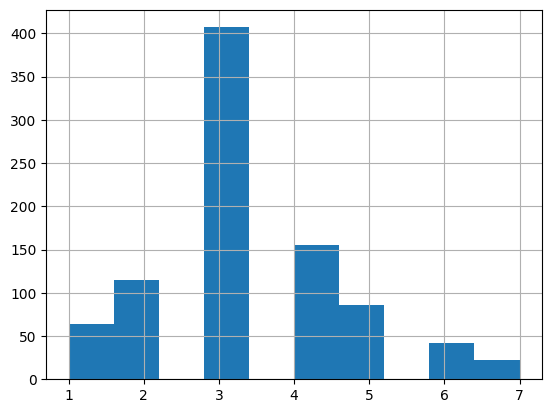

In [18]:
X_df['age_group'] = pd.cut(X_df['Age'], bins=[0, 10, 20, 30, 40, 50, 60, np.inf], labels=[1, 2, 3, 4, 5, 6, 7])
X_df['age_group'].hist()

In [19]:
X_corr= X_df.corr()
X_corr['Survived'].sort_values(ascending=False)

Survived     1.000000
Fare         0.257307
Parch        0.081629
SibSp       -0.035322
age_group   -0.050480
Age         -0.064911
Pclass      -0.338481
Sex         -0.543351
Name: Survived, dtype: float64

/home/damian/test/.venv/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)


(array([ 2.,  3.,  1.,  6.,  5.,  2.,  2., 14.,  4.,  1.,  0.,  7.,  5.,
        18., 12.,  7.,  3.,  5.,  9.,  8., 12., 14.,  8.,  8.,  2.,  0.,
         2.,  6.,  3.,  4.,  0.,  7.,  0.,  2.,  7.,  0.,  2.,  0.,  0.,
         0.,  0.,  0.,  4.,  1.,  4.,  0.,  2.,  0.,  6.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  3.]),
 array([0.04845146, 0.09217654, 0.13590161, 0.17962669, 0.22335176,
        0.26707684, 0.31080191, 0.35452699, 0.39825206, 0.44197714,
        0.48570221, 0.52942729, 0.57315237, 0.61687744, 0.66060252,
        0.70432759, 0.74805267, 0.79177774, 0.83550282, 0.87922789,
        0.92295297, 0.96667804, 1.01040312, 1.05412819, 1.09785327,
        1.14157834, 1.18530342, 1.2290285 , 1.27275357, 1.31647865,
        1.36020372, 1.4039288 , 1.44765387, 1.49137895, 1.53510402,
        1.5788291 , 1.62255417, 1.66627925, 1.71000432, 1.7537294 ,
        1.79745448, 1.84117955, 1.88490463, 1.9286297 , 

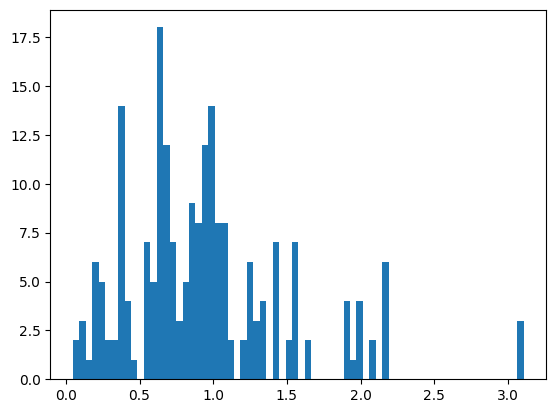

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(X_df[['Fare']])

scaled = pd.DataFrame(scaled, columns=['Fare'], index=X_df.index)

plt.hist(np.sqrt(scaled), bins=70)

array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>,
        <Axes: title={'center': 'Sex'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

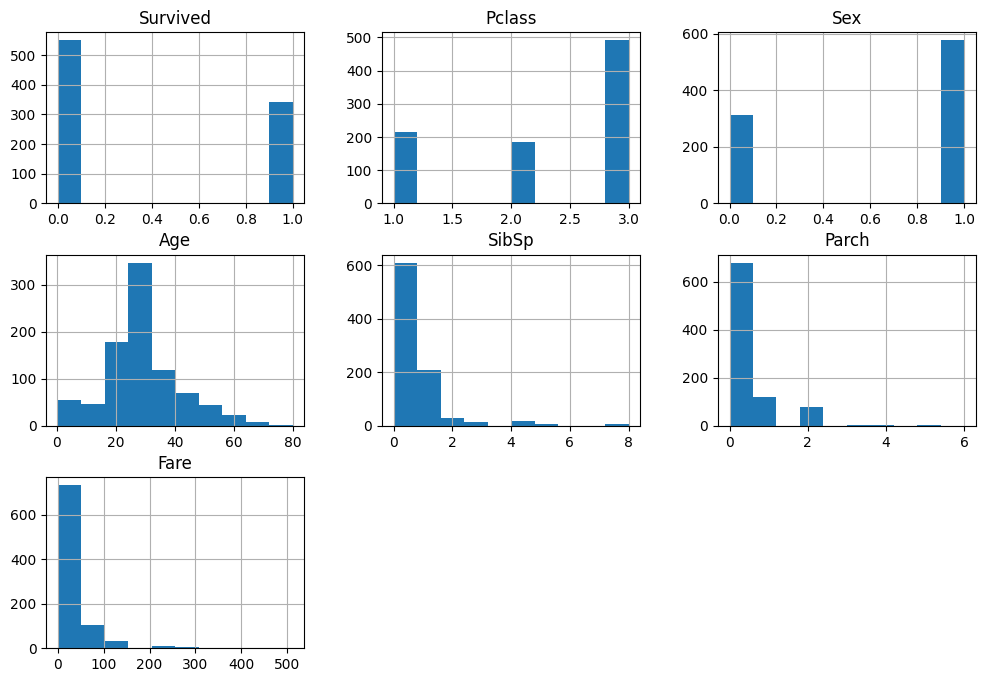

In [21]:
X_df.hist(figsize=(12,8))

In [22]:
titanic_mf = titanic[['Sex']]
titanic_mf.head(3)

,Sex
0,male
1,female
2,female


In [23]:
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer

titanic_mf_n = OrdinalEncoder().fit_transform(titanic_mf)
titanic_mf_n[:5]

array([[1.],
       [0.],
       [0.],
       [0.],
       [1.]])

## Pipelines

In [24]:
#def our own class
from sklearn.base import BaseEstimator, TransformerMixin

class SSsqrt(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        self.scaler = StandardScaler()
        self.X = X
        return self

In [25]:
from sklearn.pipeline import Pipeline, make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
large_num_pipeline = make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(np.sqrt, feature_names_out='one-to-one') ,StandardScaler())
cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore'))
mf_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OrdinalEncoder())
minmax_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), MinMaxScaler(feature_range=(-1,1)))

In [26]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([("nums",num_pipeline, ['Age', 'SibSp', 'Parch']), ("large_nums", large_num_pipeline, ['Fare']),
                                   ("mf", mf_pipeline, ['Sex']), ("cat", cat_pipeline, ['Embarked']), 
                                   ('unchanged', minmax_pipeline, ['Pclass'])], remainder='drop')

In [27]:
X_train, y_train = titanic.drop(['Survived'], axis=1), titanic['Survived']

In [28]:
X_prepared = preprocessing.fit_transform(X_train)
X_prepared

array([[-0.56573582,  0.43279337, -0.47367361, ...,  0.        ,
         1.        ,  1.        ],
       [ 0.6638609 ,  0.43279337, -0.47367361, ...,  0.        ,
         0.        , -1.        ],
       [-0.25833664, -0.4745452 , -0.47367361, ...,  0.        ,
         1.        ,  1.        ],
       ...,
       [-0.10463705,  0.43279337,  2.00893337, ...,  0.        ,
         1.        ,  1.        ],
       [-0.25833664, -0.4745452 , -0.47367361, ...,  0.        ,
         0.        , -1.        ],
       [ 0.20276213, -0.4745452 , -0.47367361, ...,  1.        ,
         0.        ,  1.        ]], shape=(891, 9))

In [29]:
preprocessing.get_feature_names_out()

array(['nums__Age', 'nums__SibSp', 'nums__Parch', 'large_nums__Fare',
       'mf__Sex', 'cat__Embarked_C', 'cat__Embarked_Q', 'cat__Embarked_S',
       'unchanged__Pclass'], dtype=object)

In [30]:
titanic_corr['Survived'].sort_values(ascending=False)

Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
Pclass     -0.338481
Sex        -0.543351
Name: Survived, dtype: float64

In [31]:
X_prepared_x = X_prepared.copy()
X_prepared_x = pd.DataFrame(X_prepared_x, columns=preprocessing.get_feature_names_out(), index=titanic.index)
X_prepared_x['Survived'] = titanic['Survived']
X_prepared_x

,nums__Age,nums__SibSp,nums__Parch,large_nums__Fare,mf__Sex,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,unchanged__Pclass,Survived
0,-0.565736,0.432793,-0.473674,-0.733117,1.0,0.0,0.0,1.0,1.0,0
1,0.663861,0.432793,-0.473674,1.219822,0.0,1.0,0.0,0.0,-1.0,1
2,-0.258337,-0.474545,-0.473674,-0.691495,0.0,0.0,0.0,1.0,1.0,1
3,0.433312,0.432793,-0.473674,0.827232,0.0,0.0,0.0,1.0,-1.0,1
4,0.433312,-0.474545,-0.473674,-0.683984,1.0,0.0,0.0,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...
886,-0.181487,-0.474545,-0.473674,-0.423054,1.0,0.0,0.0,1.0,0.0,0
887,-0.796285,-0.474545,-0.473674,0.212604,0.0,0.0,0.0,1.0,-1.0,1
888,-0.104637,0.432793,2.008933,-0.002955,0.0,0.0,0.0,1.0,1.0,0
889,-0.258337,-0.474545,-0.473674,0.212604,1.0,1.0,0.0,0.0,-1.0,1


In [32]:
X_prepared_xcorr = X_prepared_x.corr()
X_prepared_xcorr['Survived'].sort_values(ascending=False)

Survived             1.000000
large_nums__Fare     0.312508
cat__Embarked_C      0.168240
nums__Parch          0.081629
cat__Embarked_Q      0.003650
nums__SibSp         -0.035322
nums__Age           -0.064911
cat__Embarked_S     -0.149683
unchanged__Pclass   -0.338481
mf__Sex             -0.543351
Name: Survived, dtype: float64

## Trying out different models

In [33]:
from sklearn.linear_model import SGDClassifier

sgd_pipeline = make_pipeline(preprocessing, SGDClassifier(random_state=52))

sgd_pipeline.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('sgdclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('large_nums', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
from sklearn.model_selection import cross_val_score, cross_val_predict

cross_val_score(sgd_pipeline, X_train, y_train, cv=5, scoring='accuracy')

array([0.73743017, 0.78651685, 0.74157303, 0.76966292, 0.7752809 ])

In [35]:
from sklearn.ensemble import RandomForestClassifier

forest_pipeline = make_pipeline(preprocessing, RandomForestClassifier(random_state=52))

forest_pipeline.fit(X_train, y_train)

cross_val_score(forest_pipeline, X_train, y_train, cv=5, scoring='accuracy')

array([0.79329609, 0.80898876, 0.84831461, 0.7752809 , 0.84831461])

In [36]:
from sklearn.svm import SVC

svc_pipeline = make_pipeline(preprocessing, SVC(random_state=52))

svc_pipeline.fit(X_train, y_train)

(cross_val_score(svc_pipeline, X_train, y_train, cv=5, scoring='accuracy')).mean()

np.float64(0.8237838177138912)

In [37]:
from sklearn.neighbors import KNeighborsClassifier

knc_pipeline = make_pipeline(preprocessing, KNeighborsClassifier())

knc_pipeline.fit(X_train, y_train)

cross_val_score(knc_pipeline, X_train, y_train, cv=5, scoring="accuracy")

array([0.76536313, 0.76404494, 0.8258427 , 0.83707865, 0.81460674])

In [38]:
#testing out our best model ---> SVC
y_pred = cross_val_predict(svc_pipeline, X_train, y_train, cv=5)

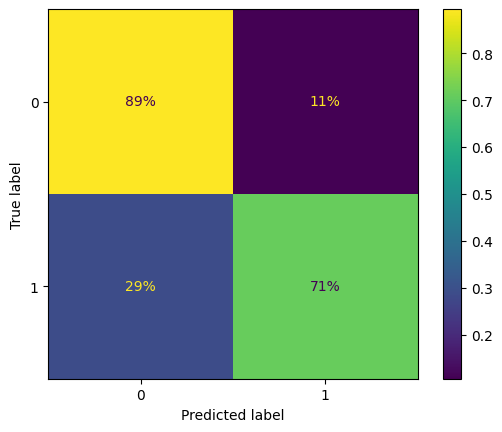

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train, y_pred, normalize='true', values_format='.0%')

## Fine tunnig our model

In [40]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([("preprocessing", preprocessing), ("svc", SVC(random_state=52))])

params = [{"svc__C": [1.4, 1.6, 1.8, 2.1], "svc__gamma" : [0.1, 0.15, 0.2, 0.25, 0.3]}]


grid_res = GridSearchCV(full_pipeline, params, scoring="accuracy", cv=5)
grid_res.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=52))])
,param_grid,"[{'svc__C': [1.4, 1.6, ...], 'svc__gamma': [0.1, 0.15, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('nums', ...), ('large_nums', ...), ...]"


In [41]:
pd.DataFrame(grid_res.cv_results_).sort_values(by="mean_test_score", ascending=False).head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_svc__C,param_svc__gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
7,0.017047,0.000330,0.006966,0.000266,1.6,0.20,"{'svc__C': 1.6, 'svc__gamma': 0.2}",0.837989,0.814607,0.814607,0.814607,0.870787,0.830519,0.022077,1
12,0.016905,0.000234,0.007000,0.000208,1.8,0.20,"{'svc__C': 1.8, 'svc__gamma': 0.2}",0.832402,0.814607,0.820225,0.808989,0.870787,0.829402,0.022098,2
3,0.018480,0.001655,0.007413,0.000314,1.4,0.25,"{'svc__C': 1.4, 'svc__gamma': 0.25}",0.837989,0.820225,0.808989,0.803371,0.876404,0.829396,0.026312,3
17,0.016851,0.000293,0.006733,0.000038,2.1,0.20,"{'svc__C': 2.1, 'svc__gamma': 0.2}",0.837989,0.808989,0.820225,0.803371,0.876404,0.829396,0.026312,3
10,0.016762,0.000145,0.006742,0.000028,1.8,0.10,"{'svc__C': 1.8, 'svc__gamma': 0.1}",0.832402,0.825843,0.814607,0.814607,0.848315,0.827155,0.012585,5


In [42]:
final_model = grid_res.best_estimator_

In [81]:
## aditionally random forest evaluating

forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)

full_pipeline_forest = make_pipeline(preprocessing, forest_clf)

full_pipeline_forest.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('large_nums', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
cross_val_score(full_pipeline_forest, X_train, y_train, cv=3, scoring="accuracy")

array([0.76094276, 0.82154882, 0.7979798 ])

## Evaluating with a test set

In [43]:
def load_test_data():
    if not Path('datasets/titanic.tgz').is_file():
        Path('datasets').mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve('https://homl.info/titanic.tgz', 'datasets/titanic.tgz')
        with tarfile.open('datasets/titanic.tgz') as titanic_tarfile:
            titanic_tarfile.extractall(path='datasets')
    return pd.read_csv(Path('datasets/titanic/test.csv'))

titanic_test = load_test_data()
# X_test = titanic_test.copy().drop('Survived', axis=1)
# y_test = titanic_test['Survived']

titanic_test.head(1)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q


In [83]:
y_test_predictions = final_model.predict(titanic_test)
y_test_predictions

y_test_predictions_forest = full_pipeline_forest.predict(titanic_test)

In [85]:
titanic_res = titanic_test.copy()
titanic_res['Survived'] = y_test_predictions_forest
titanic_res = titanic_res[['PassengerId' , 'Survived']]
titanic_res

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [86]:
titanic_res.to_csv('data2.csv', index=False)